In [2]:
import os
import sys
import time
import numpy as np
import xarray as xr
from glob import glob

In [3]:
import cmaps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

%matplotlib inline

In [5]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu

In [6]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [7]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [12]:
vars_verif = [
    'Fairbanks_T2_1d_max',
    'Fairbanks_T2_1h_max',
    'Fairbanks_T2_30d_max',
    'Fairbanks_T2_7d_max',
    'Fort_Bragg_PRECT_1d_max',
    'Fort_Bragg_PRECT_3d_max',
    'Fort_Bragg_PRECT_5d_max',
    'Fort_Bragg_SPEI_09_mean',
    'Fort_Bragg_SPEI_09_min',
    'Fort_Bragg_SPEI_48_mean',
    'Fort_Bragg_SPEI_48_min',
    'Guam_SPEI_03_mean',
    'Guam_SPEI_03_min',
    'Guam_SPEI_48_mean',
    'Guam_SPEI_48_min',
    'Pituffik_FT_days',
    'Pituffik_MDD',
    'Yuma_PG_PRECT_1d_max',
    'Yuma_PG_PRECT_7d_max',
    'Yuma_PG_SPEI_24_mean',
    'Yuma_PG_SPEI_24_min',
    'Yuma_PG_SPEI_48_mean',
    'Yuma_PG_SPEI_48_min',
]

Group = {
    'group1': ['Fairbanks_T2_1d_max', 'Fairbanks_T2_1h_max', 'Fairbanks_T2_30d_max', 'Fairbanks_T2_7d_max'],
    'group2': ['Fort_Bragg_PRECT_1d_max', 'Fort_Bragg_PRECT_3d_max', 'Fort_Bragg_PRECT_5d_max',],
    'group3': ['Fort_Bragg_SPEI_09_mean', 'Fort_Bragg_SPEI_09_min', 'Fort_Bragg_SPEI_48_mean', 'Fort_Bragg_SPEI_48_min',],
    'group4': ['Guam_SPEI_03_mean', 'Guam_SPEI_03_min', 'Guam_SPEI_48_mean', 'Guam_SPEI_48_min',],
    'group5': ['Pituffik_FT_days', 'Pituffik_MDD',],
    'group6': ['Yuma_PG_PRECT_1d_max', 'Yuma_PG_PRECT_7d_max',],
    'group7': ['Yuma_PG_SPEI_24_mean', 'Yuma_PG_SPEI_24_min', 'Yuma_PG_SPEI_48_mean', 'Yuma_PG_SPEI_48_min',]
}

ds_EMOS = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/PP_calib/EMOS/verif_scores.zarr')
ds_BMA = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/PP_calib/BMA/verif_scores.zarr')
ds_AnEn = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/PP_calib/AnEn/verif_scores.zarr')

In [59]:
my_colors = gu.ksha_color_set_summon(color_set=0)
# cyan = my_colors['cyan']
cyan = np.array([0.4, 0.8, 1, 1])
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

In [60]:
line_keys = {}
line_keys['EMOS'] = {'linewidth': 3, 'linestyle': '-',  'color': orange, 'alpha': 1, 'zorder': 3, 'label': ''}
line_keys['BMA']  = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['AnEn'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 4, 'label': ''}

In [86]:
other_keys = {
    'group1': -0.15,
    'group2': -0.2,
    'group3': -0.15,
    'group4': -0.15,
    'group5': -0.25,
    'group6': -0.25,
    'group7': -0.15
}

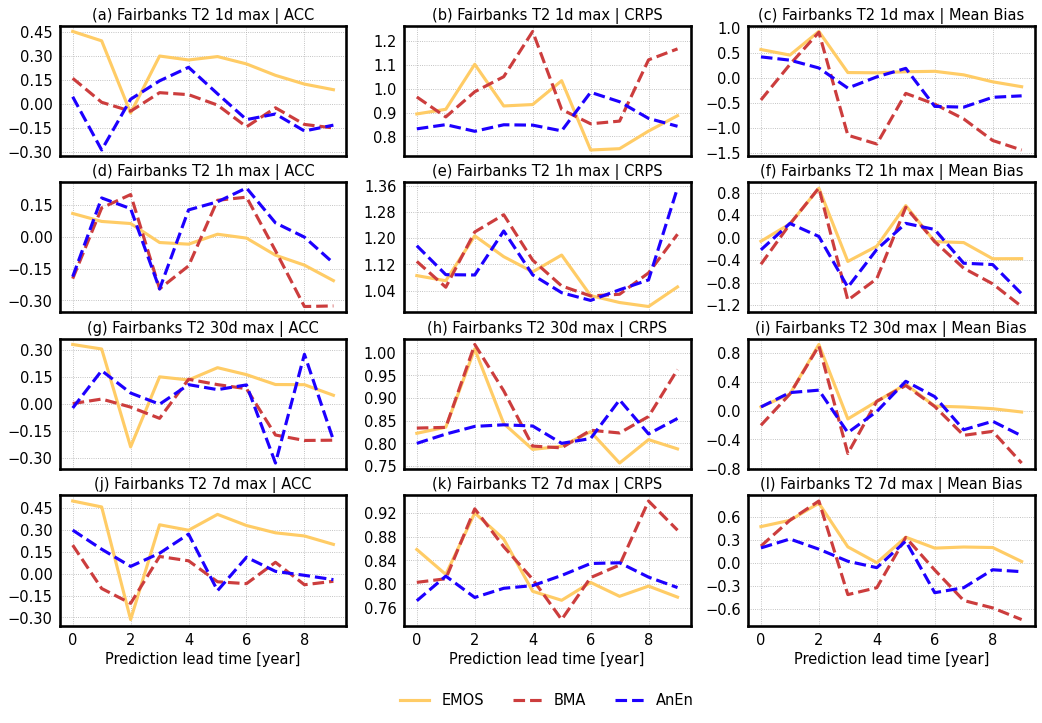

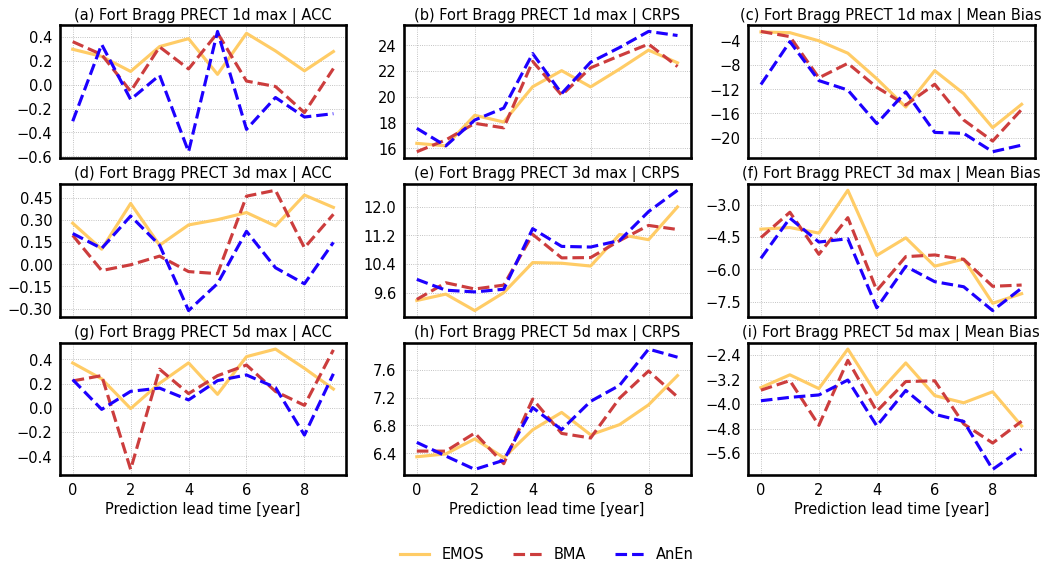

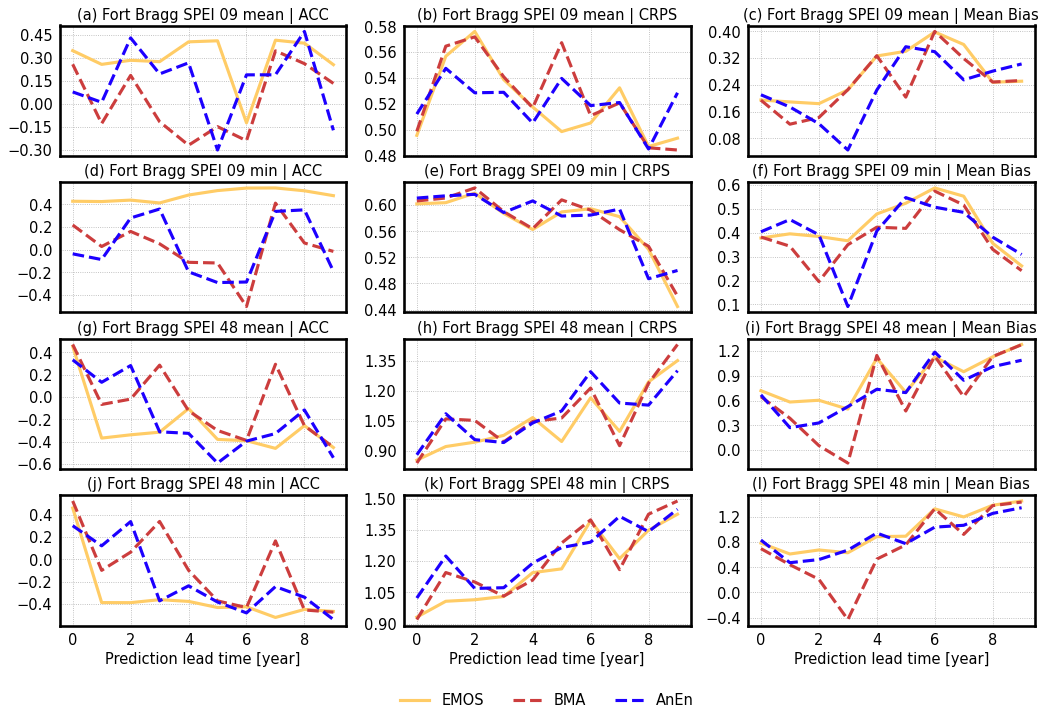

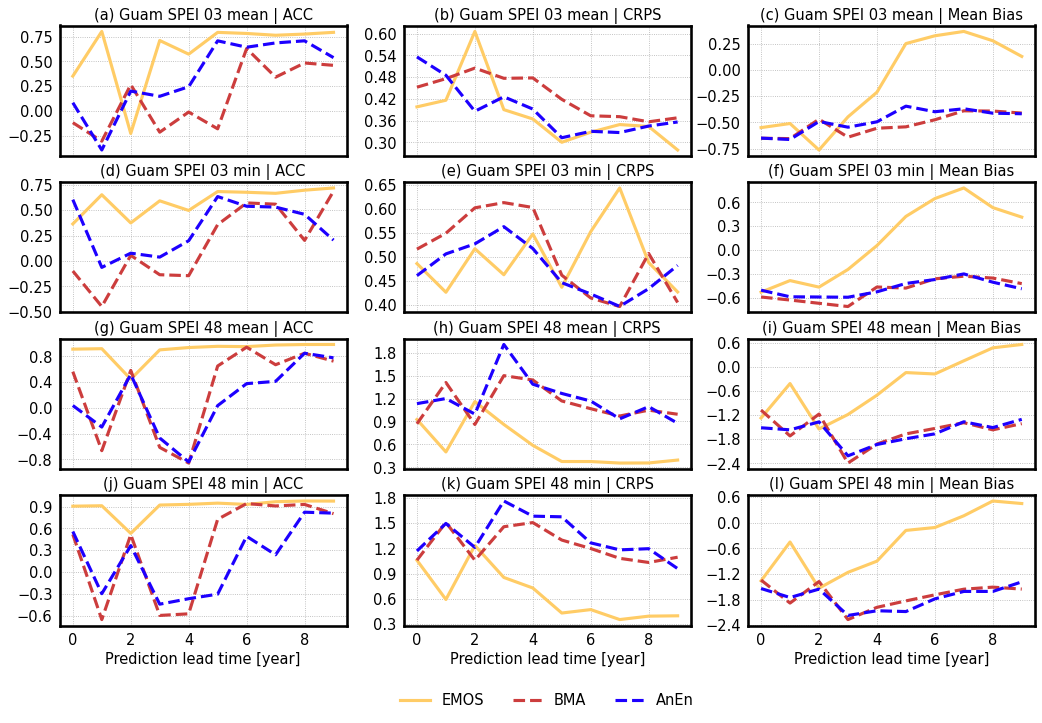

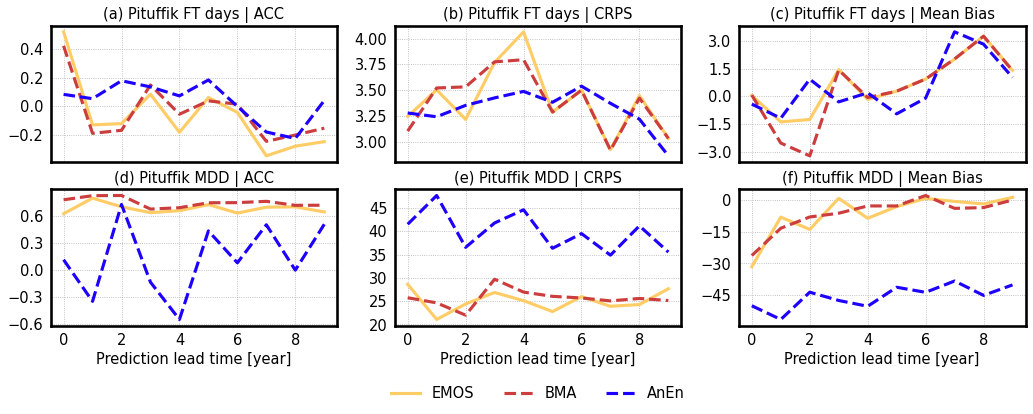

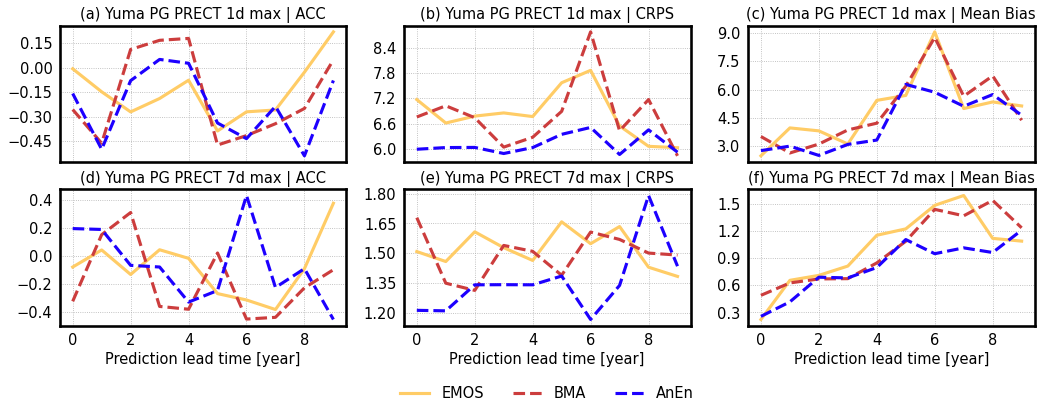

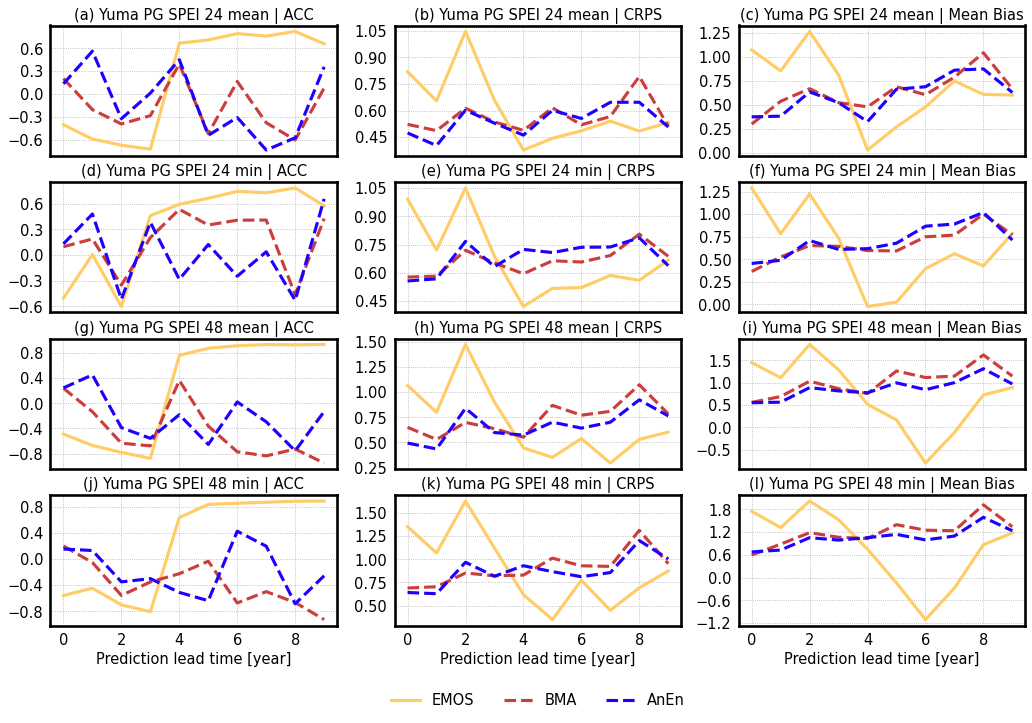

In [89]:
for i in range(1, 8):
    key = f'group{i}'
    
    N_rows = len(Group[key])
    w_row = 2
    fake_x = np.arange(10)
    varnames = [s.replace('_', ' ') for s in Group[key]]
    
    dict_scores = {
        'AnEn': ds_AnEn.sel(variable=Group[key]), 
        'EMOS': ds_EMOS.sel(variable=Group[key]), 
        'BMA': ds_BMA.sel(variable=Group[key]), 
    }
    
    fig = plt.figure(figsize=(13, w_row*N_rows), dpi=dpi_)
    gs = gridspec.GridSpec(N_rows, 3, height_ratios=[1,]*N_rows, width_ratios=[1, 1, 1])
    
    AX = []
    
    for i_row in range(N_rows):
        for i_col in range(3):
            AX.append(plt.subplot(gs[i_row, i_col]))
        AX[3*i_row].tick_params(labelleft=True, labelsize=14)
    
    for i_col in range(3):
        AX[3*(N_rows-1)+i_col].tick_params(labelbottom=True, labelsize=14)
    
    
    plt.subplots_adjust(0, 0, 1, 1, hspace=w_row/10, wspace=0.2)
    
    for ax in AX:
        ax = gu.ax_decorate_box(ax)
        ax.grid(linestyle=':')
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        
    for ax in AX:
        ax.tick_params(labelleft=True, labelsize=14)
        
    for i_col in range(3):
        ax = AX[3*(N_rows-1)+i_col]
        ax.tick_params(labelbottom=True, labelsize=14)
        ax.set_xlabel('Prediction lead time [year]', fontsize=14)
    
    label_ = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    count = 0
    
    for i_name, name in enumerate(['EMOS', 'BMA', 'AnEn']):
        ds_ = dict_scores[name]
        acc_ = ds_['ACC_calib'].values
        mb_ = ds_['Bias'].values
        crps_ = ds_['CRPS'].values
        
        for i_row in range(N_rows):
            ax_acc = AX[i_row*3+0]
            ax_crps = AX[i_row*3+1]
            ax_mb = AX[i_row*3+2]
            
            ax_acc.plot(fake_x, acc_[i_row], **line_keys[name])
            ax_crps.plot(fake_x, crps_[i_row], **line_keys[name])
            ax_mb.plot(fake_x, mb_[i_row], **line_keys[name])
            
            if i_name == 0:
                ax_acc.set_title(f'{label_[count]} {varnames[i_row]} | ACC', fontsize=14)
                count += 1
                ax_crps.set_title(f'{label_[count]} {varnames[i_row]} | CRPS', fontsize=14)
                count += 1
                ax_mb.set_title(f'{label_[count]} {varnames[i_row]} | Mean Bias', fontsize=14)
                count += 1
    
    
    handle_legneds = []
    for name in ['EMOS', 'BMA', 'AnEn']:
        handle_legneds.append(mlines.Line2D([], [], **line_keys[name]))
    
    ax_lg = fig.add_axes([0, other_keys[key], 1.0, 0.05])
    LG = ax_lg.legend(
        handle_legneds, ['EMOS', 'BMA', 'AnEn'],
        loc='center',
        bbox_to_anchor=(0.5, 0.5),
        ncol=3, 
        prop={'size': 14}
    )
    
    LG1 = gu.lg_box(LG)
    ax_lg.set_axis_off()